In [1]:
#data collection
#EDA(exploratory data analysis)& data preprocessing
#data splitting
#model selection
#model training
#model evaluation

import warnings
warnings.filterwarnings("ignore")

In [2]:
pip install scikit-learn

In [2]:
import pandas as pd
from matplotlib import pyplot as plt

In [4]:
data = pd.read_csv('homeprices.csv')

In [5]:
data

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


In [6]:
data.shape

(5, 2)

In [7]:
data.columns

Index(['area', 'price'], dtype='object')

In [8]:
data.head()

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   area    5 non-null      int64
 1   price   5 non-null      int64
dtypes: int64(2)
memory usage: 212.0 bytes


In [11]:
data.dtypes

area     int64
price    int64
dtype: object

In [12]:
data.describe()

,area,price
count,5.000000,5.000000
mean,3280.000000,626000.000000
std,540.370243,74949.983322
min,2600.000000,550000.000000
25%,3000.000000,565000.000000
50%,3200.000000,610000.000000
75%,3600.000000,680000.000000
max,4000.000000,725000.000000


In [13]:
data.isnull().sum()

area     0
price    0
dtype: int64

In [14]:
data.duplicated().sum()

np.int64(0)

In [24]:
c=data.corr()
c

,area,price
area,1.000000,0.978994
price,0.978994,1.000000


In [16]:
import seaborn as sns

<Axes: >

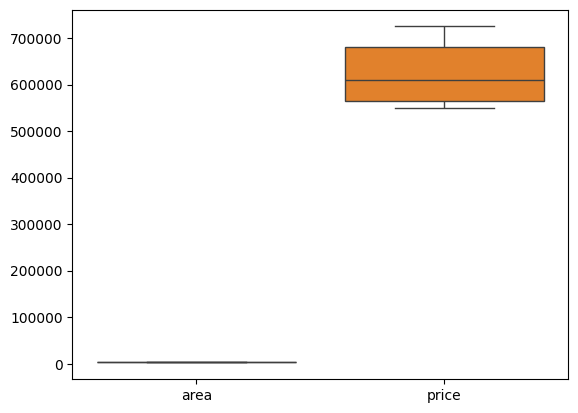

In [17]:
sns.boxplot(data)

<Axes: xlabel='area', ylabel='Count'>

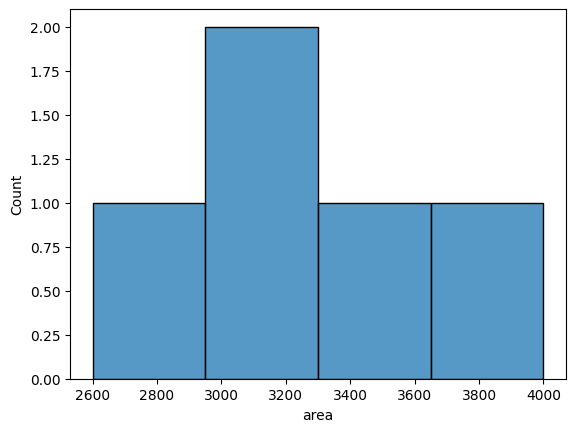

In [22]:
sns.histplot(data["area"])

<Axes: xlabel='price', ylabel='Count'>

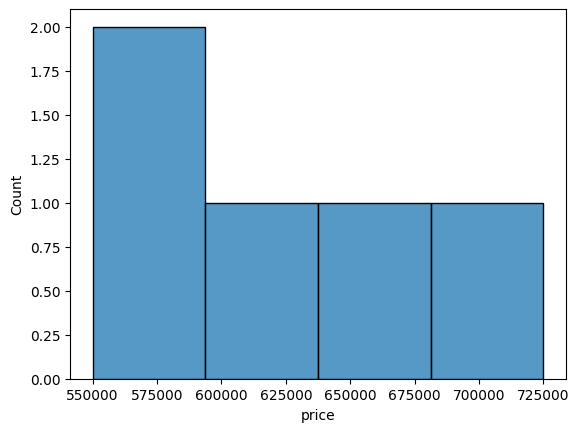

In [23]:
sns.histplot(data["price"])

<Axes: >

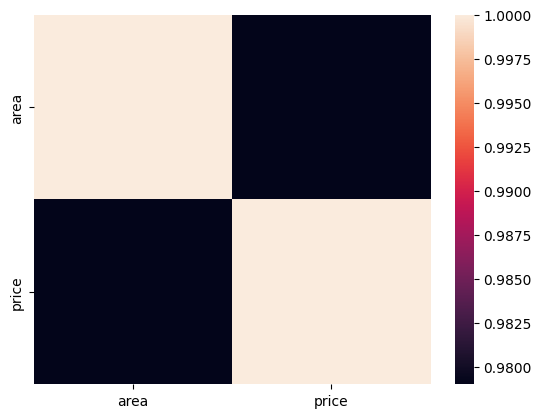

In [25]:
sns.heatmap(c)

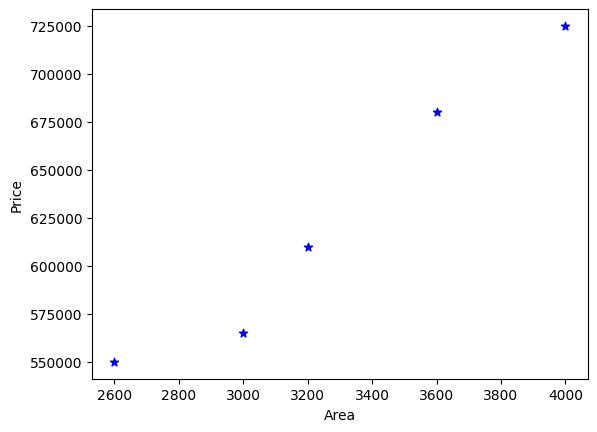

In [6]:
plt.xlabel('Area')
plt.ylabel("Price")
plt.scatter(data.area, data.price, color='blue', marker = '*')

In [27]:
#data splitting (features,target)
x=data.drop('price', axis=1) # feature  
y=data['price'] # target

In [28]:
x

,area
0,2600
1,3000
2,3200
3,3600
4,4000


In [29]:
y

0    550000
1    565000
2    610000
3    680000
4    725000
Name: price, dtype: int64

In [30]:
from sklearn.linear_model import LinearRegression
model=LinearRegression() # creating object of the Linear Regression class
model.fit(x,y) # model training

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
model.coef_

array([135.78767123])

In [32]:
model.intercept_

np.float64(180616.43835616432)

In [33]:
y_pred=model.predict(x)
y_pred

array([533664.38356164, 587979.45205479, 615136.98630137, 669452.05479452,
       723767.12328767])

In [34]:
pd.DataFrame({'True y values':y, 'Predicted y values':y_pred})


,True y values,Predicted y values
0,550000,533664.383562
1,565000,587979.452055
2,610000,615136.986301
3,680000,669452.054795
4,725000,723767.123288


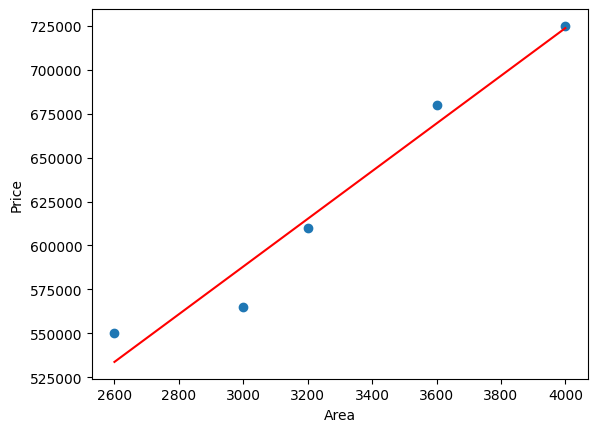

In [35]:
plt.scatter(x,y)
plt.xlabel('Area')
plt.ylabel('Price')
plt.plot(data['area'], y_pred, color = 'red')

In [36]:
model.predict([[3700]])

C:\Users\conta\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([683030.82191781])

In [17]:
model.predict([[2600],[2700],[5000]])

array([533664.38356164, 547243.15068493, 859554.79452055])

In [20]:
model.score(x,y)

0.9584301138199486

In [37]:
from sklearn.metrics import r2_score
r2=r2_score(y,y_pred)
r2

0.9584301138199486